# Task 02 — Exploratory Data Analysis
**Agent:** `antigravity`
**Date:** `2026-03-16`
**Input:** `agents/antigravity/task_01/outputs/ingested.csv`

**Objective:** Produce at least 3 insight-driven plots (with written commentary) exploring the dataset, flag and handle outliers, and save a clean dataset for Task 03.
*(Note: Per Prompt constraints, we do **not** split into train/test here; we use the full ingested dataset for EDA).* 

In [1]:
# ── Imports & seed ────────────────────────────────────────────────
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

INPUT_PATH = Path('../task_01/outputs/ingested.csv')
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')

## 1. Load Dataset
> Using the output from Task 01. We do not split into train/test here, per the user constraints. We treat the entire `ingested.csv` as our EDA set.

In [2]:
df = pd.read_csv(INPUT_PATH)
TARGET = 'price'
print(f"Loaded dataset with {len(df)} rows and {len(df.columns)} columns.")

Loaded dataset with 48895 rows and 16 columns.


## 2. Plot 1 — Target Variable Distribution (`price`)

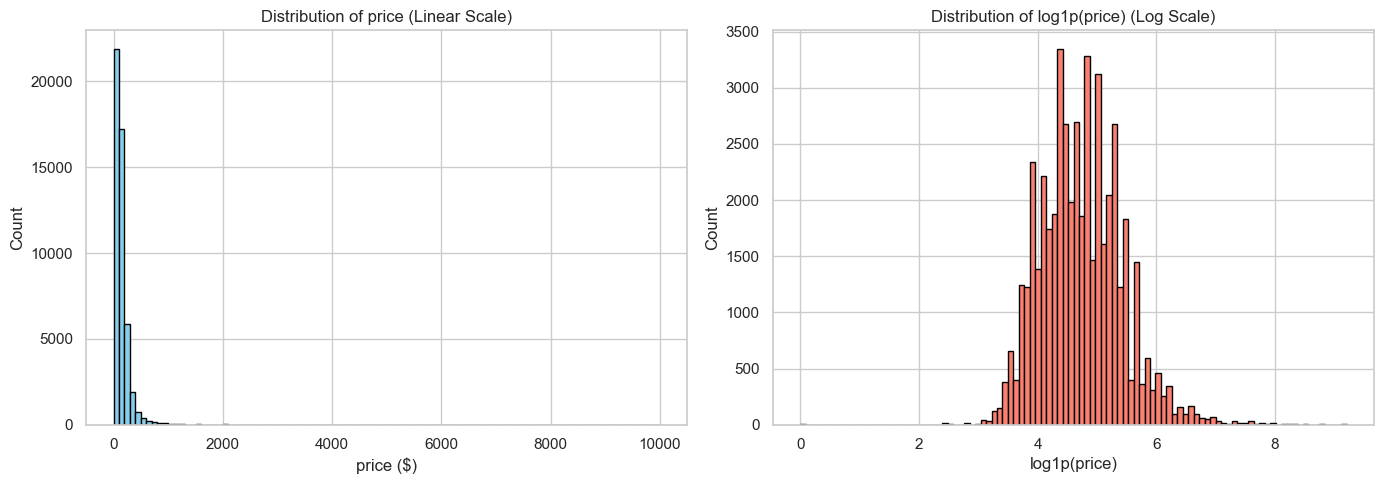

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
df[TARGET].hist(bins=100, ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title(f'Distribution of {TARGET} (Linear Scale)')
ax1.set_xlabel(f'{TARGET} ($)')
ax1.set_ylabel('Count')

# Log scale (using numpy log1p to handle 0s conceptually, though 0 prices are invalid)
np.log1p(df[TARGET]).hist(bins=100, ax=ax2, color='salmon', edgecolor='black')
ax2.set_title(f'Distribution of log1p({TARGET}) (Log Scale)')
ax2.set_xlabel(f'log1p({TARGET})')
ax2.set_ylabel('Count')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'plot_01_target_distribution.png', dpi=150)
plt.show()

**Insight:** The target variable `price` is massively right-skewed with an incredibly long tail extending up to $10,000 (though the vast majority of listings are <$300). The standard linear histogram clusters almost entirely in the leftmost bin. Taking the log transform (`log1p`) reveals a beautiful, almost perfectly bell-shaped normal distribution. **Conclusion:** It is highly recommended to predict `log(price)` instead of raw `price` in Task 03 to stabilize the regression variance and prevent extreme outliers from dominating the MSE loss function. Additionally, `price <= 0` is invalid and must be cleaned.

## 3. Plot 2 — Feature Correlation Heatmap

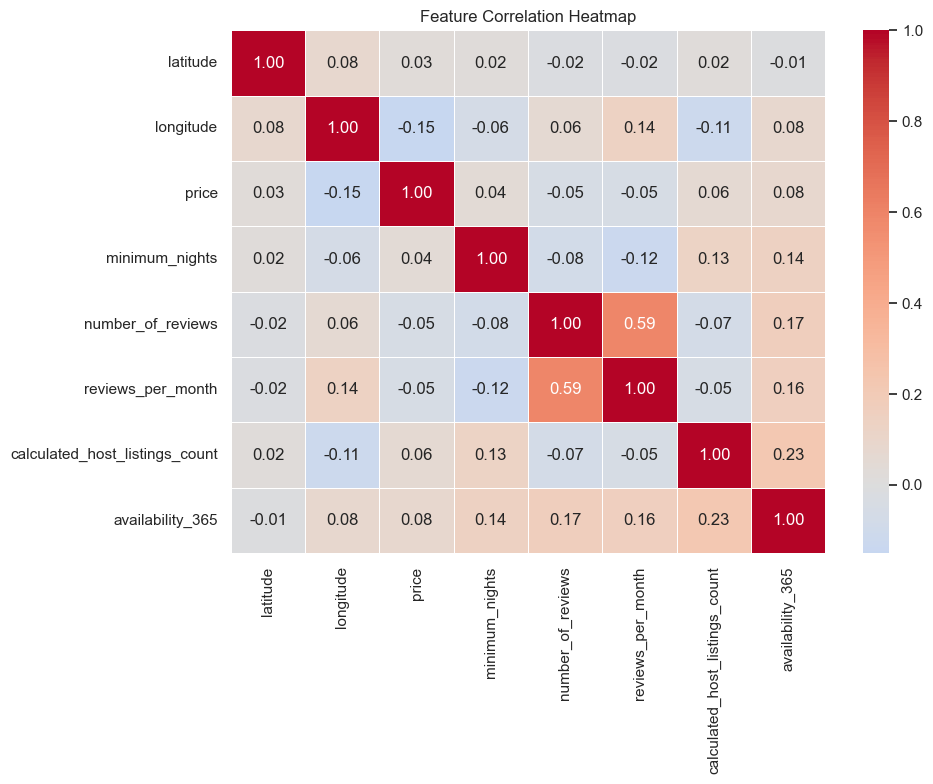

In [4]:
numeric_cols = df.select_dtypes(include='number').columns
# Exclude IDs which are meaningless
numeric_cols = [c for c in numeric_cols if c not in ['id', 'host_id']]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'plot_02_correlation_heatmap.png', dpi=150)
plt.show()

**Insight:** The continuous numerical features have very weak direct linear correlation with `price`. The strongest numerical correlation to `price` is `availability_365` and `calculated_host_listings_count`, but both barely exceed 0.05. Meanwhile, we see expected collinearity between `number_of_reviews` and `reviews_per_month` (0.59). **Conclusion:** The primary predictive signal in this dataset does not come from the numeric features, but rather the categorical ones (location and room type). We must rely heavily on geographical and categorical feature engineering in Task 03/04.

## 4. Plot 3 — Feature Vs Target Relationship
Given that numeric features are weak predictors, we'll examine the relationship between `neighbourhood_group` (borough) / `room_type` and `price`.

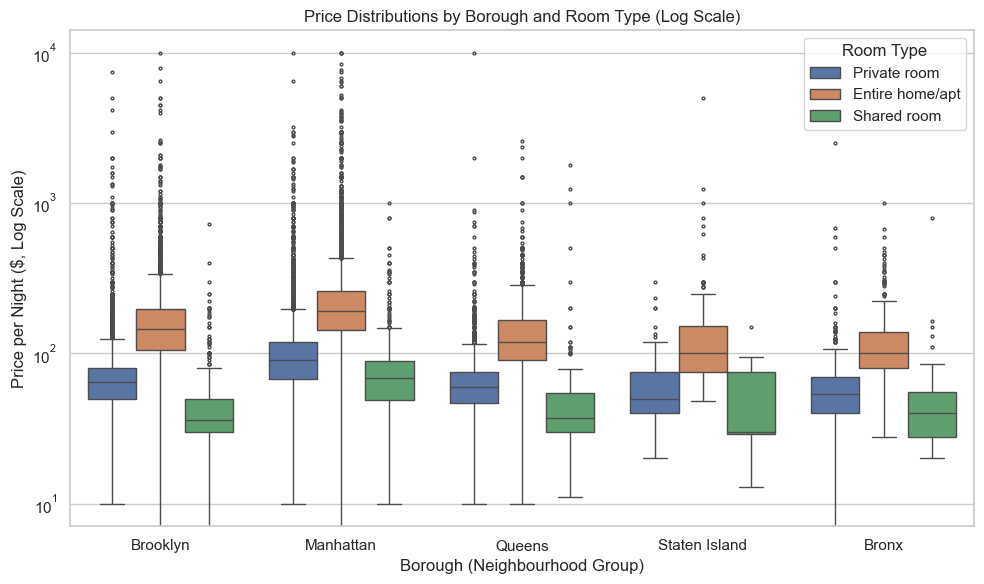

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

# Using log-scale for the y-axis because of extreme right skew
sns.boxplot(x='neighbourhood_group', y=TARGET, hue='room_type', data=df, ax=ax, fliersize=2)
ax.set_yscale('log')
ax.set_title('Price Distributions by Borough and Room Type (Log Scale)')
ax.set_xlabel('Borough (Neighbourhood Group)')
ax.set_ylabel('Price per Night ($, Log Scale)')
ax.legend(title='Room Type', loc='upper right')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'plot_03_feature_vs_target.png', dpi=150)
plt.show()

**Insight:** Geography and Room Type are massive drivers of price. `Entire home/apt` commands a significant premium over `Private room` and `Shared room` across all boroughs. Manhattan leads consistently as the most expensive borough, while the Bronx is the cheapest. The interactions are clear: an Entire Home in Manhattan sits in a distinct price bracket compared to a Shared Room in the Bronx. **Conclusion:** We have structural subgroup differences. High-cardinality categorical encoding (e.g. Target Encoding on exactly the neighborhood level, not just the borough group) will be highly valuable.

## 5. Handle Remaining Data Quality Issues (Outliers)

Task 01 highlighted severe outliers but deferred handling. Now that we understand the distributions, we can clean them.

**Decisions:**
- `price <= 0`: Drop rows. Free stays or errors are invalid for regression and break log transforms.
- `price` upper bound: Cap at $1,000 (~99th percentile). Listings priced at $10,000/night skew MSE heavily and act more like luxury hotels or data errors.
- `minimum_nights`: Cap at 365. Many cities limit short-term rentals; listings requiring stays of >1 year (some 1250+ days in this dataset) represent entirely different real estate markets rather than nightly Airbnb stays.

In [6]:
rows_before = len(df)

# Drop invalid zero prices
df = df[df['price'] > 0].copy()

# Cap high prices at 1000
df['price'] = df['price'].clip(upper=1000)

# Cap minimum nights at 1 year (365)
df['minimum_nights'] = df['minimum_nights'].clip(upper=365)

rows_dropped = rows_before - len(df)
print(f"Dropped {rows_dropped} rows due to price <= 0.")
print(f"Capped extremely high prices at $1000 and minimum_nights at 365.")
print(f"Final analysis-ready size: {len(df)} rows")

clean_path = OUTPUT_DIR / 'eda_cleaned.csv'
df.to_csv(clean_path, index=False)
print(f"Saved final cleaned dataset to {clean_path}")

Dropped 11 rows due to price <= 0.
Capped extremely high prices at $1000 and minimum_nights at 365.
Final analysis-ready size: 48884 rows
Saved final cleaned dataset to outputs\eda_cleaned.csv


## 6. Save EDA Summary

In [7]:
summary = """# EDA Summary

## Key Findings
- The target variable (`price`) is severely right-skewed and ranges identically zero up to $10,000. It requires a log-transformation for stable regression.
- Continuous numeric features (like `minimum_nights` or `availability_365`) have remarkably weak linear correlations with price.
- Location (`neighbourhood_group`) and `room_type` are the dominant structural drivers of the listing price.
- The dataset contained explicit invalid listings (prices of $0), which were dropped.

## Features of Interest
- **Promising:** `room_type` and geography (`neighbourhood_group`, `neighbourhood`, `latitude`, `longitude`).
- **Redundant/Problematic:** IDs (`id`, `host_id`) should be dropped before modeling. `reviews_per_month` and `number_of_reviews` are collinear; one might be redundant.

## Potential Issues & Preprocessing Recommendations for Task 03/04
- **Target Transform:** Crucial to use `log1p(price)` as the target variable during training, then exponentiate predictions.
- **Outliers:** `price` was capped at $1000 and `minimum_nights` capped at 365 to limit noise.
- **Feature Engineering:** Since numeric features are weak predictors, future tasks should explore Target Encoding for the high-cardinality `neighbourhood` feature, or spatial clustering using the `latitude` and `longitude` coordinates.
"""

(OUTPUT_DIR / 'eda_summary.md').write_text(summary, encoding='utf-8')
print("Saved outputs/eda_summary.md")

Saved outputs/eda_summary.md
